In [20]:
#数据获取
import baostock as bs
import pandas as pd
import os
import datetime

class StockDataLoader:
    def __init__(self, stock_code, start_date, end_date=None, data_dir='./data'):
        self.stock_code = stock_code
        self.start_date = start_date
        self.end_date = end_date if end_date else datetime.datetime.now().strftime('%Y-%m-%d')
        self.data_dir = data_dir
        
        if not os.path.exists(self.data_dir):
            os.makedirs(self.data_dir)
            
        self.file_path = os.path.join(self.data_dir, f"{stock_code}_{start_date}_{self.end_date}.csv")

    def _clean_raw_data(self, df):
        """
        内部清洗逻辑：确保无论如何都返回一个 DataFrame
        """
        # 1. 拷贝一份，防止修改原始引用带来的隐患
        df = df.copy()
        
        # 2. 类型转换
        numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
        # 确保这些列存在，防止 KeyError
        valid_cols = [c for c in numeric_cols if c in df.columns]
        df[valid_cols] = df[valid_cols].apply(pd.to_numeric, errors='coerce')

        # 3. 时间标准化
        if 'time' in df.columns:
            df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S%f')
            df = df.set_index('time').sort_index()
        
        # 4. 删除多余列
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
            
        # 【关键】必须在所有缩进块之外返回 df
        return df

    def download_data(self, frequency="5"):
        # 1. 检查本地缓存
        if os.path.exists(self.file_path):
            print(f"检测到本地缓存: {self.file_path}")
            try:
                df = pd.read_csv(self.file_path, index_col='time', parse_dates=['time'])
                print(f"本地数据加载成功，行数: {len(df)}")
                return df
            except Exception as e:
                print(f"本地文件读取失败 ({e})，准备重新下载...")

        # 2. Baostock 下载
        print(f"正在连接 Baostock 下载 {self.stock_code}...")
        bs.login()
        
        rs = bs.query_history_k_data_plus(
            self.stock_code,
            "date,time,open,high,low,close,volume,amount",
            start_date=self.start_date, 
            end_date=self.end_date,
            frequency=frequency, 
            adjustflag="2"
        )

        data_list = []
        while rs.next():
            data_list.append(rs.get_row_data())
        
        bs.logout()

        if not data_list:
            raise ValueError(f"Baostock 未返回任何数据! 请检查:\n1. 股票代码是否正确 (如 'sh.600519')\n2. 日期范围 ({self.start_date} 是否在上市后)\n3. 是否是交易日")

        # 3. 转换为 DataFrame
        df = pd.DataFrame(data_list, columns=rs.fields)
        
        # 4. 执行清洗
        df = self._clean_raw_data(df)
        
        # 【防御性检查】确保清洗后 df 依然存在
        if df is None:
            raise ValueError("严重错误：_clean_raw_data 返回了 None，请检查代码缩进！")

        # 5. 保存
        try:
            df.to_csv(self.file_path)
            print(f"数据已下载并清洗，保存至: {self.file_path}")
        except Exception as e:
            print(f"警告: 数据保存失败 ({e})，但将返回内存中的 DataFrame")

        return df

    def resample_data(self, df, rule='60min'):
        """
        重采样：从 5分钟 (含噪音) -> 小时/日线 (趋势)
        """
        # 确保 df 索引是时间类型
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
            
        agg_dict = {
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum',
            'amount': 'sum'
        }
        
        # 仅对存在的列进行聚合
        valid_agg = {k: v for k, v in agg_dict.items() if k in df.columns}
        
        df_res = df.resample(rule, label='right', closed='right').agg(valid_agg)
        df_res = df_res.dropna()
        
        print(f"重采样完成: {len(df)} (原始) -> {len(df_res)} ({rule})")
        return df_res



In [21]:
#只有从2019开始的分钟线数据
Data=StockDataLoader("sh.600519", "2019-01-01").download_data()
df_raw = Data
df_raw

检测到本地缓存: ./data\sh.600519_2019-01-01_2026-01-26.csv
本地数据加载成功，行数: 82272


,open,high,low,close,volume,amount
time,,,,,,
2019-01-02 09:35:00,520.781405,522.506016,516.529640,519.517828,1552766,945850400.0
2019-01-02 09:40:00,519.577592,520.798480,517.511473,517.554162,395656,240900640.0
2019-01-02 09:45:00,517.383408,518.237176,515.564882,515.803937,332316,201314560.0
2019-01-02 09:50:00,516.179595,516.529640,514.156165,516.145444,201370,121501600.0
2019-01-02 09:55:00,516.145444,516.529640,511.407032,511.483871,361837,217579824.0
...,...,...,...,...,...,...
2026-01-23 14:40:00,1335.360000,1336.770000,1332.710000,1334.000000,581350,775614285.0
2026-01-23 14:45:00,1334.380000,1337.650000,1334.380000,1337.170000,91407,122180265.0
2026-01-23 14:50:00,1337.160000,1337.280000,1334.380000,1335.200000,194476,259865095.0


In [23]:
#特征工程

import pandas as pd
import numpy as np

def perform_feature_engineering(df_raw):
    """
    修改版特征工程：引入多尺度分析（Multi-scale Analysis）
    通过计算极长周期的趋势和全局位置，模拟人类“压缩时间维度”观察大趋势的视觉直觉。
    
    输入: df_raw (5分钟原始数据)
    输出: X (特征矩阵), y (标签), df_final (完整数据)
    """
    
    # ==========================================
    # 1. 物理降噪：保持 60分钟线重采样
    # ==========================================
    agg_dict = {
        'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last',
        'volume': 'sum', 'amount': 'sum'
    }
    if not isinstance(df_raw.index, pd.DatetimeIndex):
        df_raw.index = pd.to_datetime(df_raw.index)
        
    df = df_raw.resample('60min', closed='right', label='right').agg(agg_dict).dropna()
    
    # ==========================================
    # 2. 构造“多尺度”描述特征 (核心修改点)
    # ==========================================
    
    # --- A. 扩展均线系统 (跨越：日 -> 周 -> 月 -> 季) ---
    # 4小时/天。20=1周，60=3周，120=1.5个月，240=3个月（季度线）
    windows = [5, 20, 60, 120, 240]
    for w in windows:
        df[f'ma_{w}'] = df['close'].rolling(window=w).mean()
    
    # --- B. 多尺度趋势斜率 (模拟“压缩时间”看坡度) ---
    def calculate_slope(series, period=3):
        return (series - series.shift(period)) / series.shift(period)

    # 包含中长期斜率：这是模型“看清大势”的关键
    df['slope_ma20'] = calculate_slope(df['ma_20'])
    df['slope_ma60'] = calculate_slope(df['ma_60'])
    df['slope_ma120'] = calculate_slope(df['ma_120']) # 新增：月度趋势
    df['slope_ma240'] = calculate_slope(df['ma_240']) # 新增：季度趋势（宏观视野）
    
    # --- C. 趋势加速度 (二阶导数：判断大趋势是否在减速或变向) ---
    df['accel_ma60'] = df['slope_ma60'].diff(3)
    
    # --- D. 全局位置参考 (模拟“看全景图”时的相对高低感) ---
    # 计算当前价格在过去3个月（240根K线）内的百分比位置
    rolling_min = df['close'].rolling(window=240).min()
    rolling_max = df['close'].rolling(window=240).max()
    df['rel_pos_240'] = (df['close'] - rolling_min) / (rolling_max - rolling_min + 1e-9)
    
    # --- E. 多尺度乖离度 (描述“偏离大势”的程度) ---
    df['dist_ma5_ma20'] = (df['ma_5'] - df['ma_20']) / df['ma_20']
    df['dist_ma20_ma60'] = (df['ma_20'] - df['ma_60']) / df['ma_60']
    df['dist_ma60_ma240'] = (df['ma_60'] - df['ma_240']) / df['ma_240'] # 新增：中长期偏离
    
    # --- F. 归一化波动率 ---
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    true_range = np.max(pd.concat([high_low, high_close, low_close], axis=1), axis=1)
    df['atr_pct'] = true_range.rolling(window=20).mean() / df['close']

    # --- G. 动量特征 ---
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))
    
    df['rsi_ma20'] = calculate_rsi(df['ma_20'], window=14)

    # --- H. 滞后特征 (保持模型对历史演变的记忆) ---
    # 关注中长期特征的演变
    feature_cols_base = ['slope_ma20', 'slope_ma60', 'slope_ma120', 'rel_pos_240', 'dist_ma20_ma60', 'atr_pct', 'rsi_ma20']
    lags = [1, 2, 4, 8] 
    for col in feature_cols_base:
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # ==========================================
    # 3. 标签生成 (保持原始逻辑不变)
    # ==========================================
    prediction_horizon = 8  
    smooth_window = 4       
    curr_smooth = df['close'].rolling(window=smooth_window).mean()
    future_smooth = df['close'].rolling(window=smooth_window).mean().shift(-prediction_horizon)
    df['trend_return'] = (future_smooth - curr_smooth) / (curr_smooth + 1e-9)
    threshold = df['atr_pct'] * 0.8
    
    conditions = [
        (df['trend_return'] > threshold),
        (df['trend_return'] < -threshold)
    ]
    choices = [2, 1]
    df['label'] = np.select(conditions, choices, default=0)

    # ==========================================
    # 4. 清洗与输出
    # ==========================================
    df_final = df.dropna()
    
    # 排除原始价格和中间变量，仅保留逻辑特征
    exclude_keywords = ['open', 'high', 'low', 'close', 'volume', 'amount', 'ma_', 'label', 'trend_return', 'atr']
    feature_cols = [c for c in df_final.columns if not any(k == c for k in exclude_keywords)]
    
    X = df_final[feature_cols]
    y = df_final['label']
    
    return X, y, df_final

# 假设 df_raw 已经存在 (来自上一步)
# 执行特征工程
if 'df_raw' in locals():
    X, y, df_clean = perform_feature_engineering(df_raw)
else:
    print("请先运行数据获取代码以生成 df_raw")

X

,ma_5,ma_20,ma_60,ma_120,ma_240,slope_ma20,slope_ma60,slope_ma120,slope_ma240,accel_ma60,...,dist_ma20_ma60_lag4,dist_ma20_ma60_lag8,atr_pct_lag1,atr_pct_lag2,atr_pct_lag4,atr_pct_lag8,rsi_ma20_lag1,rsi_ma20_lag2,rsi_ma20_lag4,rsi_ma20_lag8
time,,,,,,,,,,,,,,,,,,,,,
2019-03-19 12:00:00,684.100393,670.209161,657.255650,642.170068,603.257314,0.009160,0.001849,0.002627,0.003631,-0.001306,...,0.009292,0.001346,0.013720,0.013898,0.013680,0.012767,100.0,100.0,100.0,97.528500
2019-03-19 14:00:00,683.297851,671.844126,657.548777,642.666747,603.985721,0.008904,0.001762,0.002548,0.003655,-0.000904,...,0.012321,0.002607,0.013901,0.013720,0.013600,0.012639,100.0,100.0,100.0,98.678627
2019-03-19 15:00:00,680.313078,673.492325,657.595877,643.074848,604.706479,0.008019,0.001154,0.002258,0.003619,-0.001256,...,0.014507,0.004805,0.013413,0.013901,0.013898,0.013745,100.0,100.0,100.0,100.000000
2019-03-20 10:00:00,680.622142,674.843413,657.857984,643.489637,605.430118,0.006915,0.000916,0.002055,0.003602,-0.000933,...,0.017198,0.006714,0.013525,0.013413,0.013720,0.014217,100.0,100.0,100.0,100.000000
2019-03-20 11:00:00,679.256113,675.257491,657.924151,643.921502,606.129532,0.005081,0.000571,0.001952,0.003549,-0.001191,...,0.019708,0.009292,0.013440,0.013525,0.013901,0.013680,100.0,100.0,100.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-21 12:00:00,1368.584000,1378.906000,1404.783833,1404.300653,1411.213141,-0.003045,-0.001560,-0.000503,-0.000721,-0.001414,...,-0.016133,-0.011021,0.004238,0.004452,0.004520,0.005140,0.0,0.0,0.0,0.000000
2026-01-21 14:00:00,1366.118000,1377.399500,1403.795833,1404.002558,1410.875350,-0.003069,-0.001842,-0.000557,-0.000714,-0.001320,...,-0.016960,-0.012593,0.004258,0.004238,0.004350,0.004798,0.0,0.0,0.0,0.000000
2026-01-21 15:00:00,1361.620000,1375.508000,1402.546833,1403.609808,1410.502193,-0.003528,-0.002215,-0.000677,-0.000745,-0.001235,...,-0.017596,-0.013892,0.004093,0.004258,0.004452,0.004909,0.0,0.0,0.0,0.000000


In [24]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def train_and_eval_lightgbm(data, date_col, feature_cols, target_col, initial_months=12):
    """
    使用 LightGBM 进行滚动窗口预测
    """
    # 排序与时间周期处理
    df = data.sort_values(by=date_col).copy()
    df['period_month'] = df[date_col].dt.to_period('M')
    unique_months = df['period_month'].unique()
    
    if len(unique_months) <= initial_months:
        raise ValueError("数据月份不足")
        
    all_predictions = []
    all_targets = []
    all_dates = []
    
    print(f">>> LightGBM 启动: 总月份 {len(unique_months)}, 初始训练 {initial_months} 个月")
    
    # LightGBM 参数 (针对金融噪声数据的优化配置)
    params = {
        'objective': 'multiclass',
        'num_class': 3,  # 你的类别数: 0, 1, 2
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': 31,       # 控制复杂度，太高会过拟合
        'learning_rate': 0.05,  # 降低学习率，增加迭代次数
        'feature_fraction': 0.8,# 随机选特征，防止对某一特征过拟合
        'bagging_fraction': 0.8,# 随机选样本
        'bagging_freq': 5,
        'min_data_in_leaf': 50, # 金融数据噪点多，叶子节点样本要大一点
        'random_state': 42,
        'verbosity': -1
    }

    # 滚动训练循环
    for i in range(initial_months, len(unique_months)):
        current_pred_month = unique_months[i]
        
        # 扩展窗口：训练集不断变大
        train_mask = df['period_month'] < current_pred_month
        test_mask = df['period_month'] == current_pred_month
        
        X_train = df.loc[train_mask, feature_cols]
        y_train = df.loc[train_mask, target_col]
        X_test = df.loc[test_mask, feature_cols]
        y_test = df.loc[test_mask, target_col]
        test_dates = df.loc[test_mask, date_col]
        
        if len(X_test) == 0: continue

        # 创建 LGB 数据集
        lgb_train = lgb.Dataset(X_train, y_train)
        
        # 训练模型 (num_boost_round=100)
        clf = lgb.train(params, lgb_train, num_boost_round=100)
        
        # 预测 (输出概率 -> 转为类别)
        y_pred_prob = clf.predict(X_test)
        y_pred = [np.argmax(line) for line in y_pred_prob]
        
        all_predictions.extend(y_pred)
        all_targets.extend(y_test)
        all_dates.extend(test_dates)
        
        if i % 5 == 0:
            print(f"进度: 预测 {current_pred_month} 完成...")

    # 汇总结果
    results_df = pd.DataFrame({
        'date': all_dates,
        'y_true': all_targets,
        'y_pred': all_predictions
    })
    
    return results_df, clf



>>> LightGBM 启动: 总月份 83, 初始训练 12 个月
进度: 预测 2020-06 完成...
进度: 预测 2020-11 完成...
进度: 预测 2021-04 完成...
进度: 预测 2021-09 完成...
进度: 预测 2022-02 完成...
进度: 预测 2022-07 完成...
进度: 预测 2022-12 完成...
进度: 预测 2023-05 完成...
进度: 预测 2023-10 完成...
进度: 预测 2024-03 完成...
进度: 预测 2024-08 完成...
进度: 预测 2025-01 完成...
进度: 预测 2025-06 完成...
进度: 预测 2025-11 完成...

LightGBM 最终分类报告
              precision    recall  f1-score   support

           0       0.37      0.28      0.32      2444
           1       0.37      0.32      0.34      2393
           2       0.35      0.49      0.41      2325

    accuracy                           0.36      7162
   macro avg       0.36      0.36      0.35      7162
weighted avg       0.36      0.36      0.35      7162



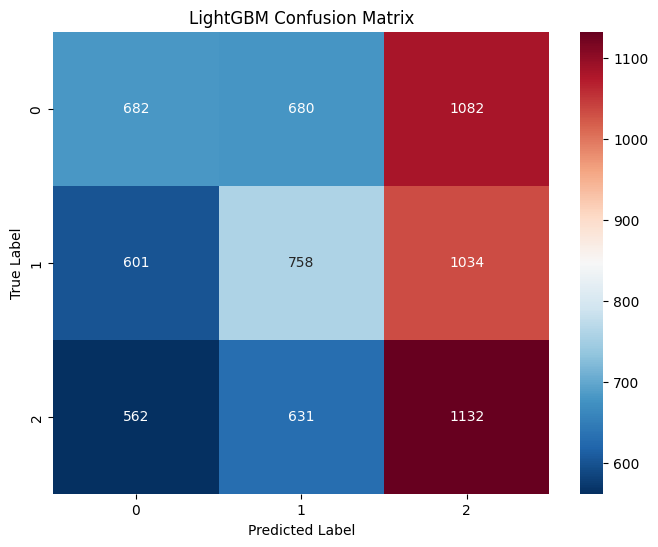

C:\Users\xyp\AppData\Local\Temp\ipykernel_31344\3693887096.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_acc = eval_res.set_index('date').resample('M')['is_correct'].mean()


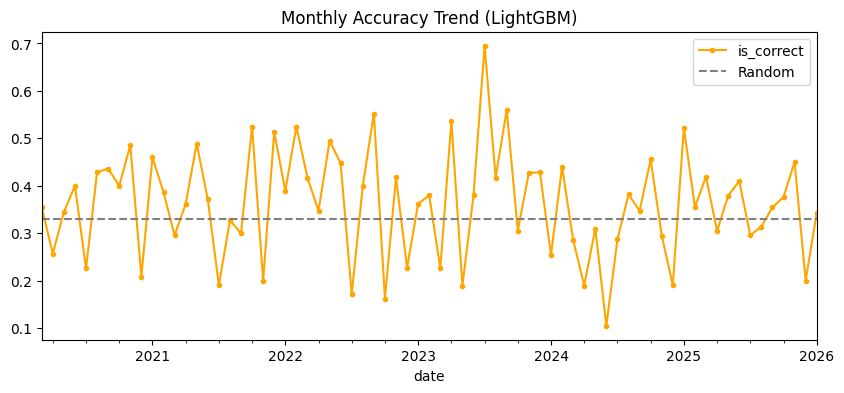

C:\Users\xyp\AppData\Local\Temp\ipykernel_31344\3693887096.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


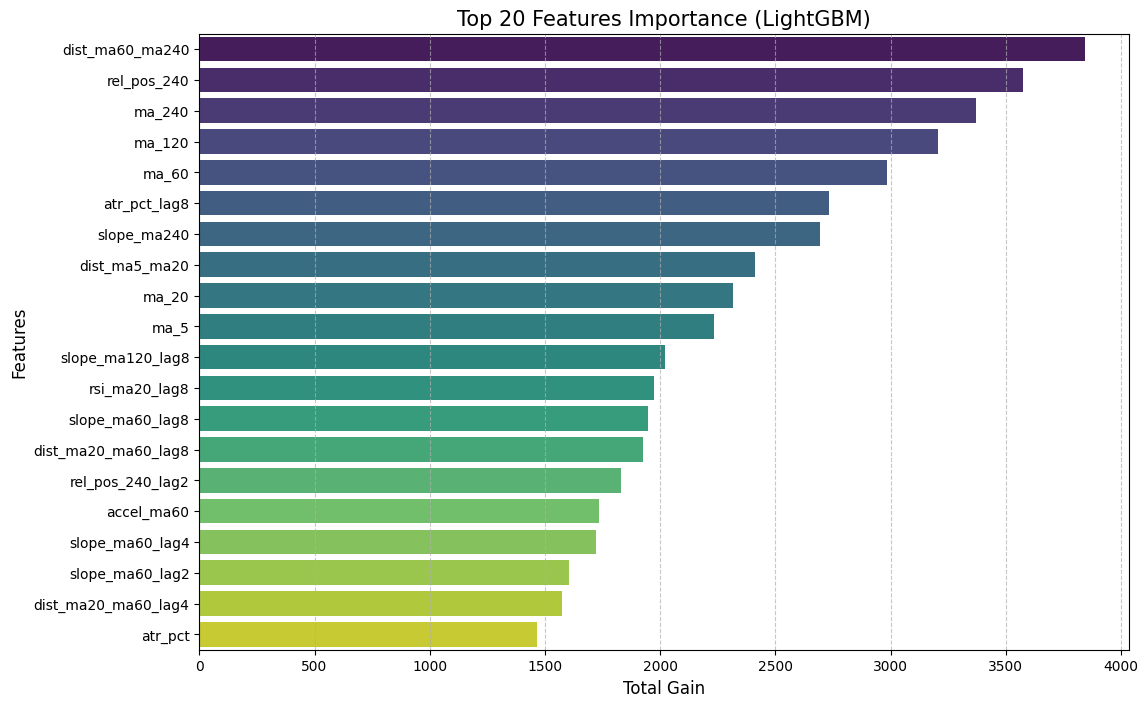

Top 10 关键特征:
            Feature   Importance
13  dist_ma60_ma240  3843.323545
10      rel_pos_240  3574.009960
4            ma_240  3369.052626
3            ma_120  3204.630000
2             ma_60  2985.154565
39     atr_pct_lag8  2734.383933
8       slope_ma240  2695.237951
11    dist_ma5_ma20  2411.638891
1             ma_20  2315.495024
0              ma_5  2233.275281


In [25]:
# ==========================================
# 调用新的 LightGBM 函数
# ==========================================

# 假设 df_clean 和 X 已经准备好 (来自你之前的特征工程步骤)
if 'df_clean' in locals():
    df_train_ready = df_clean.reset_index()
    feature_list = X.columns.tolist()
    
    # 执行训练
    eval_res,model = train_and_eval_lightgbm(
        data=df_train_ready,
        date_col='time',
        feature_cols=feature_list,
        target_col='label',
        initial_months=12
    ) 

    # ==========================================
    # 结果分析 (重点看分类报告)
    # ==========================================
    y_true = eval_res['y_true']
    y_pred = eval_res['y_pred']
    
    print("\n" + "="*40)
    print("LightGBM 最终分类报告")
    print("="*40)
    print(classification_report(y_true, y_pred))
    
    # 混淆矩阵可视化
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r') # 红蓝配色对比更强烈
    plt.title('LightGBM Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 准确率趋势
    eval_res['is_correct'] = (eval_res['y_true'] == eval_res['y_pred']).astype(int)
    monthly_acc = eval_res.set_index('date').resample('M')['is_correct'].mean()
    
    plt.figure(figsize=(10, 4))
    monthly_acc.plot(marker='.', color='orange')
    plt.axhline(0.33, color='grey', linestyle='--', label='Random')
    plt.title("Monthly Accuracy Trend (LightGBM)")
    plt.legend()
    plt.show()


    # 2. 获取特征重要性数据
    importance_df = pd.DataFrame({
        'Feature': feature_list,
        'Importance': model.feature_importance(importance_type='gain') # 'gain'表示该特征对模型精度的总贡献
    })

    # 3. 排序并取前20个特征
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

    # 4. 可视化
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Top 20 Features Importance (LightGBM)', fontsize=15)
    plt.xlabel('Total Gain', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # 打印数值列表查看
    print("Top 10 关键特征:")
    print(importance_df.head(10))

else:
    print("请先运行上面的特征工程代码块生成 df_clean")